In [34]:
import kagglehub

path = kagglehub.dataset_download("sudalairajkumar/covid19-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid19-in-india' dataset.
Path to dataset files: /kaggle/input/covid19-in-india


In [35]:
import os
print(os.listdir(path))

['StatewiseTestingDetails.csv', 'covid_vaccine_statewise.csv', 'covid_19_india.csv']


In [36]:
import pandas as pd
file_path = os.path.join(path, "covid_19_india.csv")
df = pd.read_csv(file_path)
df

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812


In [37]:
print("Shape:", df.shape)
print("Columns:", df.columns)
print("Data Type:", df.dtypes)

Shape: (18110, 9)
Columns: Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed'],
      dtype='object')
Data Type: Sno                          int64
Date                        object
Time                        object
State/UnionTerritory        object
ConfirmedIndianNational     object
ConfirmedForeignNational    object
Cured                        int64
Deaths                       int64
Confirmed                    int64
dtype: object


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


In [39]:
df.isnull().sum()

,0
Sno,0
Date,0
Time,0
State/UnionTerritory,0
ConfirmedIndianNational,0
ConfirmedForeignNational,0
Cured,0
Deaths,0
Confirmed,0


In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.drop_duplicates()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812


In [42]:
df["Date"] = pd.to_datetime(df["Date"])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Sno                       18110 non-null  int64         
 1   Date                      18110 non-null  datetime64[ns]
 2   Time                      18110 non-null  object        
 3   State/UnionTerritory      18110 non-null  object        
 4   ConfirmedIndianNational   18110 non-null  object        
 5   ConfirmedForeignNational  18110 non-null  object        
 6   Cured                     18110 non-null  int64         
 7   Deaths                    18110 non-null  int64         
 8   Confirmed                 18110 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.2+ MB


In [44]:
df.isnull().sum()

,0
Sno,0
Date,0
Time,0
State/UnionTerritory,0
ConfirmedIndianNational,0
ConfirmedForeignNational,0
Cured,0
Deaths,0
Confirmed,0


In [45]:
df["Recovered"] = df["Cured"]

In [46]:
df["Active"] = df["Confirmed"] - df["Deaths"] - df["Recovered"]

In [47]:
df.tail(10)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,Recovered,Active
18100,18101,2021-08-11,8:00 AM,Puducherry,-,-,119115,1800,121766,119115,851
18101,18102,2021-08-11,8:00 AM,Punjab,-,-,582791,16322,599573,582791,460
18102,18103,2021-08-11,8:00 AM,Rajasthan,-,-,944700,8954,953851,944700,197
18103,18104,2021-08-11,8:00 AM,Sikkim,-,-,25095,356,28018,25095,2567
18104,18105,2021-08-11,8:00 AM,Tamil Nadu,-,-,2524400,34367,2579130,2524400,20363
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353,638410,8112
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660,77811,2076
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462,334650,444
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812,1685492,545
18109,18110,2021-08-11,8:00 AM,West Bengal,-,-,1506532,18252,1534999,1506532,10215


In [48]:
df.sample(10)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,Recovered,Active
13396,13397,2021-04-03,8:00 AM,Arunachal Pradesh,-,-,16785,56,16846,16785,5
890,891,2020-04-12,5:00 PM,Tripura,-,-,0,0,2,0,2
4746,4747,2020-08-02,8:00 AM,Chandigarh,-,-,683,18,1079,683,378
9424,9425,2020-12-13,8:00 AM,Puducherry,-,-,36479,619,37444,36479,346
6197,6198,2020-09-12,8:00 AM,Meghalaya,-,-,1889,24,3447,1889,1534
12715,12716,2021-03-15,8:00 AM,Chandigarh,-,-,21650,358,23096,21650,1088
12543,12544,2021-03-10,8:00 AM,Jammu and Kashmir,-,-,124367,1965,127191,124367,859
5272,5273,2020-08-17,8:00 AM,Chhattisgarh,-,-,10235,141,15471,10235,5095
11815,11816,2021-02-18,8:00 AM,Chandigarh,-,-,20832,348,21322,20832,142
621,622,2020-04-04,6:00 PM,Assam,-,-,0,0,24,0,24


In [49]:
# create our state_level summary
# use .max() instead of .sum() bcz of cumulative data
state_data = (
    df.groupby("State/UnionTerritory")
    [["Confirmed", "Deaths", "Recovered", "Active"]]
    .max()
    .reset_index()
)

In [50]:
state_data["Recovery_Rate"] = state_data["Recovered"] / state_data["Confirmed"].replace(0,pd.NA)*100


In [51]:
state_data["Death_Rate"] = state_data["Deaths"] / state_data["Confirmed"].replace(0,pd.NA)*100

In [52]:
state_data["Recovery_Rate"] = state_data["Recovery_Rate"].round(2)
state_data["Death_Rate"] = state_data["Death_Rate"].round(2)

In [53]:
# Top 10
top10 = (
    state_data.sort_values(by="Confirmed", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

In [54]:
top10

,State/UnionTerritory,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
0,Maharashtra,6363442,134201,6159676,701614,96.80,2.11
1,Maharashtra***,6229596,130753,6000911,97932,96.33,2.10
2,Kerala,3586693,18004,3396184,445692,94.69,0.50
3,Karnataka,2921049,36848,2861499,605515,97.96,1.26
4,Karanataka,2885238,36197,2821491,27550,97.79,1.25
5,Tamil Nadu,2579130,34367,2524400,313048,97.88,1.33
6,Andhra Pradesh,1985182,13564,1952736,211554,98.37,0.68
7,Uttar Pradesh,1708812,22775,1685492,310783,98.64,1.33
8,West Bengal,1534999,18252,1506532,132181,98.15,1.19
9,Delhi,1436852,25068,1411280,103424,98.22,1.74


/tmp/ipykernel_1732/1966532373.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1732/1966532373.py:7: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


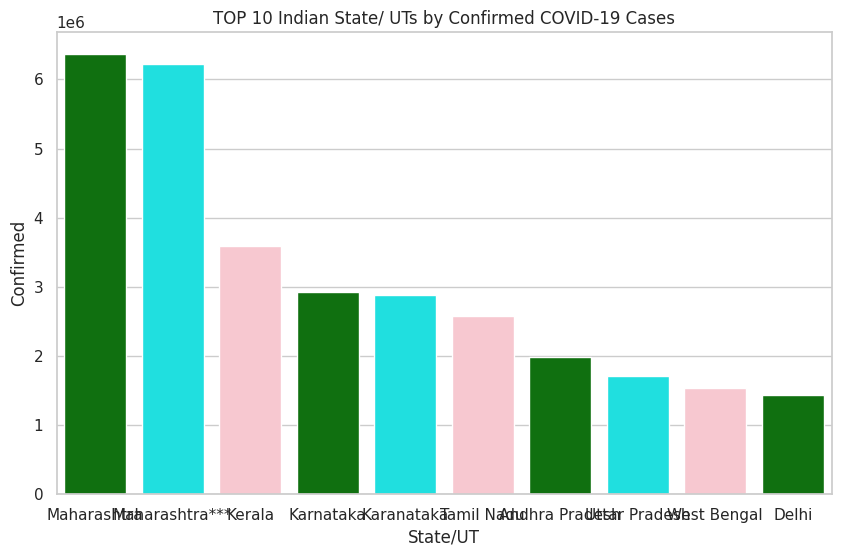

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x = "State/UnionTerritory",
    y = "Confirmed",
    # color = 'forestgreen',
    palette = ["Green", "cyan", "pink"]
)

plt.title("TOP 10 Indian State/ UTs by Confirmed COVID-19 Cases")
plt.xlabel("State/UT")
plt.ylabel("Confirmed")

plt.show()

/tmp/ipykernel_1732/1818764924.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1732/1818764924.py:4: UserWarning: 
The palette list has fewer values (3) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


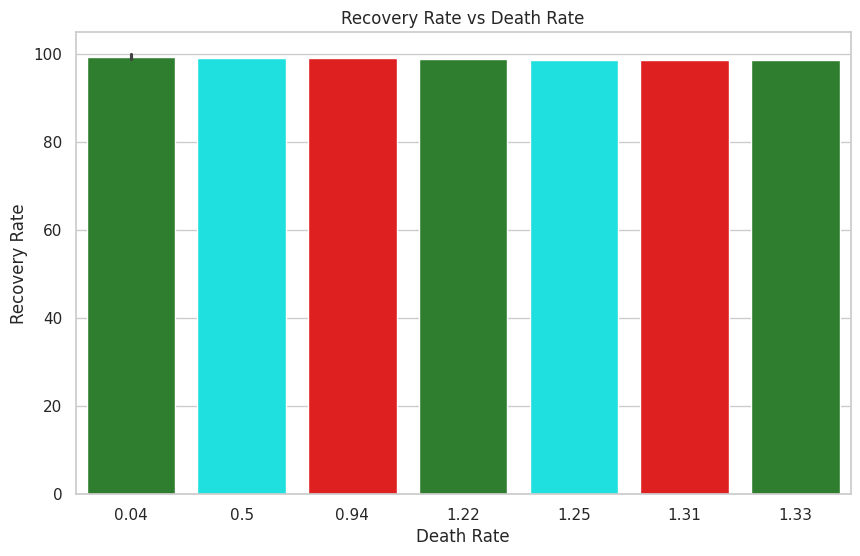

In [56]:
# Recovery rate vs Death rate
rate_data = state_data.sort_values("Recovery_Rate", ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rate_data,
    x="Death_Rate",
    y="Recovery_Rate",
    palette=["forestgreen", "cyan", "red"]
)
plt.title("Recovery Rate vs Death Rate")
plt.xlabel("Death Rate")
plt.ylabel("Recovery Rate")
plt.show()

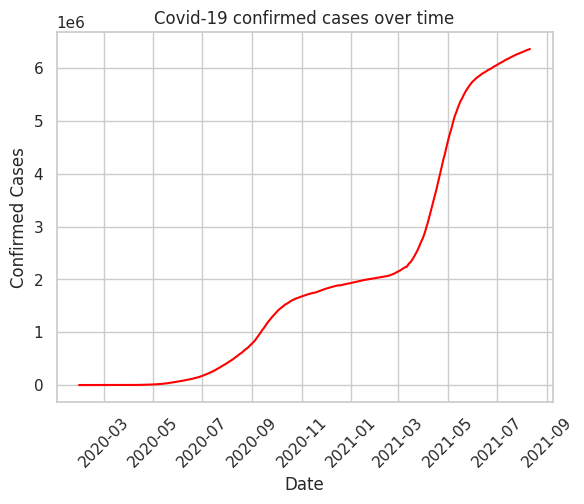

In [57]:
daily_cases = (
    df.groupby("Date")
    ["Confirmed"]
    .max()
    .reset_index()
)
sns.lineplot(
    data=daily_cases,
    x="Date",
    y="Confirmed",
    color="red"
)
plt.title("Covid-19 confirmed cases over time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()


In [58]:
# Top 10 states by death
death = (
    state_data.sort_values(by="Deaths", ascending=False)
    .head(10)
    # .reset_index(drop=True)
)

In [59]:
death

,State/UnionTerritory,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
27,Maharashtra,6363442,134201,6159676,701614,96.80,2.11
28,Maharashtra***,6229596,130753,6000911,97932,96.33,2.10
21,Karnataka,2921049,36848,2861499,605515,97.96,1.26
20,Karanataka,2885238,36197,2821491,27550,97.79,1.25
38,Tamil Nadu,2579130,34367,2524400,313048,97.88,1.33
12,Delhi,1436852,25068,1411280,103424,98.22,1.74
43,Uttar Pradesh,1708812,22775,1685492,310783,98.64,1.33
45,West Bengal,1534999,18252,1506532,132181,98.15,1.19
22,Kerala,3586693,18004,3396184,445692,94.69,0.50
35,Punjab,599573,16322,582791,79963,97.20,2.72


/tmp/ipykernel_1732/3210689214.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1732/3210689214.py:7: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


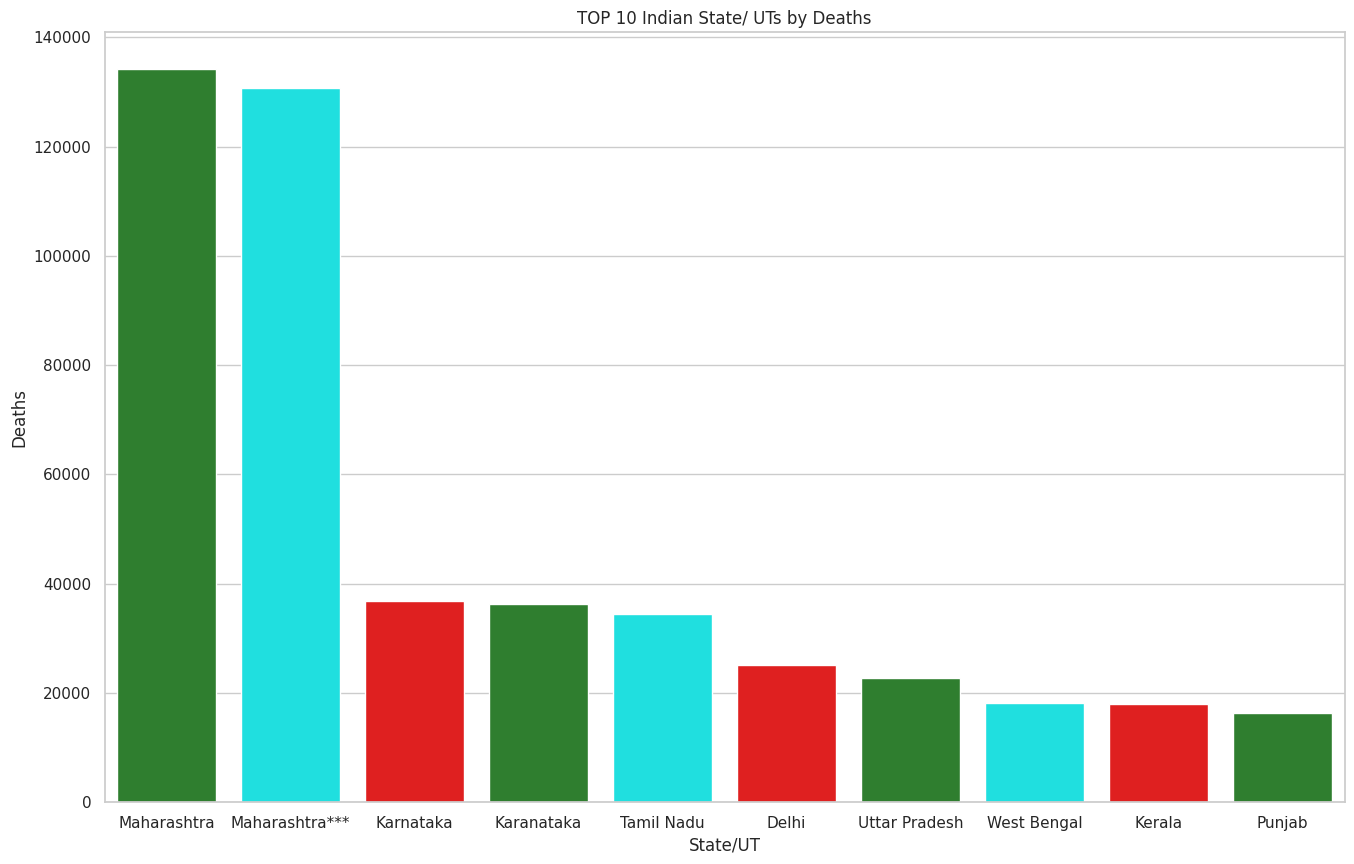

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 10))
sns.barplot(
    data=death,
    x = "State/UnionTerritory",
    y = "Deaths",
    # color = 'forestgreen',
    palette = ["forestgreen", "cyan", "red"]
)

plt.title("TOP 10 Indian State/ UTs by Deaths")
plt.xlabel("State/UT")
plt.ylabel("Deaths")

plt.show()